# Desigualdade Racial no Mercado de Trabalho de Alagoas (2013-2024)

Equipe: 
Maria Raquel Farias Cezário 
Vitória Leandra Santos Camilo
Wellington Domingos dos Santos 

### Pergunta de Pesquisa e Objetivos
Pergunta de Pesquisa: Existem diferenças estatisticamente significativas nas taxas de desemprego e nos rendimentos médios habituais entre a população negra e não-negra no estado de Alagoas ao longo do período de 2013 a 2024?

Objetivo Geral: Analisar a evolução temporal e a significância estatística das disparidades raciais no mercado de trabalho de Alagoas.

Objetivos Específicos:
Comparar as taxas médias de desemprego trimestrais entre negros e não-negros.
Comparar a média dos rendimentos habituais recebidos por ambos os grupos.
Aplicar testes de hipóteses estatísticas robustos para validar se as diferenças observadas são estruturais ou fruto do acaso.
Conectar os achados empíricos com as teorias de distribuições de probabilidade ministradas na disciplina.


### PARTE 1: Manipulação da base de dados(importação, tratamento, limpeza e seleção)

Importação das bibliotecas base

In [5]:
import pandas as pd # permite importar arquivos (CSV, Excel, bancos SQL), filtrar linhas, agrupar dados, tratar valores vazios e fazer cálculos rapidamente.
import numpy as np # calcula os dados organizando-os em matrizes e não apenas listas(são coleções de dados de diversos tipo, como uma coluna de um excel, porém cada célula com um dado que pode ser de um tipo diferente ), só que é mais rápido do que somente ler por pandas e consome menos memória
import matplotlib.pyplot as plt # permite criar gráficos de forma simples , ele funciona como uma tela em branco que você pode desenhar o gráfico, inserir os dados, plotar etc...
import seaborn as sns # permite criar gráficos de maneira mais moderna e ler os dados nele em tempo real calculando estatísticas, a biblioteca possui funções para calcular frequência, distribuições etc.
from scipy import stats # permite calcular estatísticas, como média, mediana, moda, desvio padrão, variância, correlação, regressão etc...
import basedosdados as bd # permite acessar os dados do governo brasileiro de forma simples, ele possui funções para baixar os dados, filtrar, agrupar, calcular estatísticas etc...

Acessando a PNADC via SQL pela Base dos Dados

In [6]:

billing_id = "metodosquantitativos-502513"

query = """
WITH dicionario_V2007 AS (
    SELECT
        chave AS chave_V2007,
        valor AS descricao_V2007
    FROM basedosdados.br_ibge_pnadc.dicionario
    WHERE
        TRUE
        AND nome_coluna = 'V2007'
        AND id_tabela = 'microdados'
),
dicionario_V2010 AS (
    SELECT
        chave AS chave_V2010,
        valor AS descricao_V2010
    FROM basedosdados.br_ibge_pnadc.dicionario
    WHERE
        TRUE
        AND nome_coluna = 'V2010'
        AND id_tabela = 'microdados'
),
dicionario_VD4002 AS (
    SELECT
        chave AS chave_VD4002,
        valor AS descricao_VD4002
    FROM basedosdados.br_ibge_pnadc.dicionario
    WHERE
        TRUE
        AND nome_coluna = 'VD4002'
        AND id_tabela = 'microdados'
)
SELECT
    dados.ano as ano,
    dados.trimestre as trimestre,
    dados.sigla_uf AS sigla_uf,
    diretorio_sigla_uf.nome AS sigla_uf_nome,
    dados.V1028 as V1028,
    descricao_V2007 AS V2007,
    descricao_V2010 AS V2010,
    descricao_VD4002 AS VD4002,
    dados.VD4019 as VD4019
FROM basedosdados.br_ibge_pnadc.microdados AS dados
LEFT JOIN (SELECT DISTINCT sigla,nome  FROM basedosdados.br_bd_diretorios_brasil.uf) AS diretorio_sigla_uf
    ON dados.sigla_uf = diretorio_sigla_uf.sigla
LEFT JOIN dicionario_V2007
    ON dados.V2007 = chave_V2007
LEFT JOIN dicionario_V2010
    ON dados.V2010 = chave_V2010
LEFT JOIN dicionario_VD4002
    ON dados.VD4002 = chave_VD4002

WHERE
    dados.sigla_uf = 'AL'
    AND dados.ano BETWEEN 2013 AND 2024"""
dfbase = bd.read_sql(query=query, billing_project_id=billing_id)
dfbase


Downloading: 100%|██████████|


,ano,trimestre,sigla_uf,sigla_uf_nome,V1028,V2007,V2010,VD4002,VD4019
0,2019,1,AL,Alagoas,103.542178,Mulher,Parda,None,NaN
1,2019,1,AL,Alagoas,94.548462,Homem,Branca,None,NaN
2,2019,1,AL,Alagoas,88.082072,Homem,Parda,None,NaN
3,2019,1,AL,Alagoas,86.945813,Mulher,Amarela,None,NaN
4,2019,1,AL,Alagoas,86.186219,Mulher,Parda,None,NaN
...,...,...,...,...,...,...,...,...,...
984616,2017,4,AL,Alagoas,421.083065,Homem,Parda,Pessoas ocupadas,2000.0
984617,2017,4,AL,Alagoas,436.973084,Mulher,Parda,Pessoas ocupadas,4000.0
984618,2017,4,AL,Alagoas,776.903100,Mulher,Parda,Pessoas ocupadas,4000.0
984619,2017,2,AL,Alagoas,711.134250,Mulher,Parda,Pessoas ocupadas,937.0


Renomeando as colunas

In [7]:
dfatual = dfbase.rename(columns={
    'V2007': 'sexo',
    'V2010': 'cor_ou_raca',
    'VD4002': 'condicao_ocupacao',
    'VD4019': 'rendimento_mensal',
    'V1028': 'peso_amostral',

})
dfatual

,ano,trimestre,sigla_uf,sigla_uf_nome,peso_amostral,sexo,cor_ou_raca,condicao_ocupacao,rendimento_mensal
0,2019,1,AL,Alagoas,103.542178,Mulher,Parda,None,NaN
1,2019,1,AL,Alagoas,94.548462,Homem,Branca,None,NaN
2,2019,1,AL,Alagoas,88.082072,Homem,Parda,None,NaN
3,2019,1,AL,Alagoas,86.945813,Mulher,Amarela,None,NaN
4,2019,1,AL,Alagoas,86.186219,Mulher,Parda,None,NaN
...,...,...,...,...,...,...,...,...,...
984616,2017,4,AL,Alagoas,421.083065,Homem,Parda,Pessoas ocupadas,2000.0
984617,2017,4,AL,Alagoas,436.973084,Mulher,Parda,Pessoas ocupadas,4000.0
984618,2017,4,AL,Alagoas,776.903100,Mulher,Parda,Pessoas ocupadas,4000.0
984619,2017,2,AL,Alagoas,711.134250,Mulher,Parda,Pessoas ocupadas,937.0


In [8]:
dfatual.dtypes

ano                    Int64
trimestre              Int64
sigla_uf              object
sigla_uf_nome         object
peso_amostral        float64
sexo                  object
cor_ou_raca           object
condicao_ocupacao     object
rendimento_mensal    float64
dtype: object

Selecionando as colunas da base, após renomeadas, e verificando os valores únicos de cada coluna 

In [9]:
df_base_selecionada = dfatual[['ano', 'trimestre', 'sigla_uf', 'sexo', 'cor_ou_raca', 'condicao_ocupacao', 'peso_amostral', 'rendimento_mensal']]
df_base_selecionada

,ano,trimestre,sigla_uf,sexo,cor_ou_raca,condicao_ocupacao,peso_amostral,rendimento_mensal
0,2019,1,AL,Mulher,Parda,None,103.542178,NaN
1,2019,1,AL,Homem,Branca,None,94.548462,NaN
2,2019,1,AL,Homem,Parda,None,88.082072,NaN
3,2019,1,AL,Mulher,Amarela,None,86.945813,NaN
4,2019,1,AL,Mulher,Parda,None,86.186219,NaN
...,...,...,...,...,...,...,...,...
984616,2017,4,AL,Homem,Parda,Pessoas ocupadas,421.083065,2000.0
984617,2017,4,AL,Mulher,Parda,Pessoas ocupadas,436.973084,4000.0
984618,2017,4,AL,Mulher,Parda,Pessoas ocupadas,776.903100,4000.0
984619,2017,2,AL,Mulher,Parda,Pessoas ocupadas,711.134250,937.0


In [10]:
#ver as classificações de cada variável string
print(df_base_selecionada['cor_ou_raca'].unique())

['Parda' 'Branca' 'Amarela' 'Preta' 'Indígena' 'Ignorado']


In [11]:
print(df_base_selecionada['condicao_ocupacao'].unique())

[None 'Pessoas ocupadas' 'Pessoas desocupadas']


In [12]:
print(df_base_selecionada['sexo'].unique())

['Mulher' 'Homem']


In [13]:
print(df_base_selecionada['trimestre'].unique())

<IntegerArray>
[1, 2, 3, 4]
Length: 4, dtype: Int64


In [14]:
print(df_base_selecionada['ano'].unique())

<IntegerArray>
[2019, 2022, 2020, 2023, 2024, 2014, 2017, 2021, 2016, 2015, 2018, 2013]
Length: 12, dtype: Int64


Analisando a existência de valores nulos e tratando-os

In [15]:
dfconta=df_base_selecionada.isnull().sum()
dfconta

ano                       0
trimestre                 0
sigla_uf                  0
sexo                      0
cor_ou_raca               0
condicao_ocupacao    630621
peso_amostral             0
rendimento_mensal    690387
dtype: int64

In [16]:
df_base_selecionada.dtypes

ano                    Int64
trimestre              Int64
sigla_uf              object
sexo                  object
cor_ou_raca           object
condicao_ocupacao     object
peso_amostral        float64
rendimento_mensal    float64
dtype: object

In [17]:
df_base_selecionada['condicao_ocupacao'] = df_base_selecionada['condicao_ocupacao'].fillna(0)
df_base_selecionada

,ano,trimestre,sigla_uf,sexo,cor_ou_raca,condicao_ocupacao,peso_amostral,rendimento_mensal
0,2019,1,AL,Mulher,Parda,0,103.542178,NaN
1,2019,1,AL,Homem,Branca,0,94.548462,NaN
2,2019,1,AL,Homem,Parda,0,88.082072,NaN
3,2019,1,AL,Mulher,Amarela,0,86.945813,NaN
4,2019,1,AL,Mulher,Parda,0,86.186219,NaN
...,...,...,...,...,...,...,...,...
984616,2017,4,AL,Homem,Parda,Pessoas ocupadas,421.083065,2000.0
984617,2017,4,AL,Mulher,Parda,Pessoas ocupadas,436.973084,4000.0
984618,2017,4,AL,Mulher,Parda,Pessoas ocupadas,776.903100,4000.0
984619,2017,2,AL,Mulher,Parda,Pessoas ocupadas,711.134250,937.0


In [18]:
df_base_selecionada.dtypes

ano                    Int64
trimestre              Int64
sigla_uf              object
sexo                  object
cor_ou_raca           object
condicao_ocupacao     object
peso_amostral        float64
rendimento_mensal    float64
dtype: object

Convertendo os tipos das colunas de forma manual para não retirar valores zerados

In [19]:
df_base_selecionada['sexo'] = df_base_selecionada['sexo'].astype("string")

In [20]:
df_base_selecionada['condicao_ocupacao'] = df_base_selecionada['condicao_ocupacao'].astype("string")

In [21]:
df_base_selecionada['sigla_uf'] = df_base_selecionada['sigla_uf'].astype("string")

In [22]:
df_base_selecionada['cor_ou_raca'] = df_base_selecionada['cor_ou_raca'].astype("string")

In [23]:
df_base_selecionada.dtypes

ano                           Int64
trimestre                     Int64
sigla_uf             string[python]
sexo                 string[python]
cor_ou_raca          string[python]
condicao_ocupacao    string[python]
peso_amostral               float64
rendimento_mensal           float64
dtype: object

Selecionando a base final a ser usada para a análise

In [24]:
df_base_limpa = df_base_selecionada[['ano', 'trimestre', 'sigla_uf', 'sexo', 'cor_ou_raca', 'condicao_ocupacao', 'peso_amostral', 'rendimento_mensal']]

In [25]:
df_base_limpa.dtypes

ano                           Int64
trimestre                     Int64
sigla_uf             string[python]
sexo                 string[python]
cor_ou_raca          string[python]
condicao_ocupacao    string[python]
peso_amostral               float64
rendimento_mensal           float64
dtype: object

Criando novas classificações

In [26]:
df_base_limpa['grupo_etnico'] = np.where(
    df_base_limpa['cor_ou_raca'].str.title().isin(['Preta', 'Parda']),
    'Negra',       # Se for Preta ou Parda -> 'Negra'
    'Não-Negra'    # Qualquer outra opção -> 'Não-Negra'
)
df_base_limpa


,ano,trimestre,sigla_uf,sexo,cor_ou_raca,condicao_ocupacao,peso_amostral,rendimento_mensal,grupo_etnico
0,2019,1,AL,Mulher,Parda,0,103.542178,NaN,Negra
1,2019,1,AL,Homem,Branca,0,94.548462,NaN,Não-Negra
2,2019,1,AL,Homem,Parda,0,88.082072,NaN,Negra
3,2019,1,AL,Mulher,Amarela,0,86.945813,NaN,Não-Negra
4,2019,1,AL,Mulher,Parda,0,86.186219,NaN,Negra
...,...,...,...,...,...,...,...,...,...
984616,2017,4,AL,Homem,Parda,Pessoas ocupadas,421.083065,2000.0,Negra
984617,2017,4,AL,Mulher,Parda,Pessoas ocupadas,436.973084,4000.0,Negra
984618,2017,4,AL,Mulher,Parda,Pessoas ocupadas,776.903100,4000.0,Negra
984619,2017,2,AL,Mulher,Parda,Pessoas ocupadas,711.134250,937.0,Negra


In [49]:
#exportando o arquivo para csv 
df_base_limpa.to_csv('df_base_limpa.csv', index=False)

## Parte 2 : Análise Estatística

Estatístitica descritiva

In [27]:
df_base_limpa.describe(include="all")

,ano,trimestre,sigla_uf,sexo,cor_ou_raca,condicao_ocupacao,peso_amostral,rendimento_mensal,grupo_etnico
count,984621.0,984621.0,984621,984621,984621,984621,984621.000000,294234.00000,984621
unique,<NA>,<NA>,1,2,6,3,NaN,NaN,2
top,<NA>,<NA>,AL,Mulher,Parda,0,NaN,NaN,Negra
freq,<NA>,<NA>,984621,513719,685417,630621,NaN,NaN,740678
mean,2018.215067,2.502239,NaN,NaN,NaN,NaN,161.921911,1403.07560,NaN
std,3.488192,1.118721,NaN,NaN,NaN,NaN,105.281047,2109.84041,NaN
min,2013.0,1.0,NaN,NaN,NaN,NaN,5.572822,5.00000,NaN
25%,2015.0,1.0,NaN,NaN,NaN,NaN,106.730130,600.00000,NaN
50%,2018.0,3.0,NaN,NaN,NaN,NaN,143.968077,998.00000,NaN
75%,2021.0,4.0,NaN,NaN,NaN,NaN,189.674991,1412.00000,NaN


Criando variáveis locais para uso das estatísticas e probabilidades

In [ ]:
renda_media = (
    df_base_limpa
    #  O groupby separa as linhas da tabela em blocos por grupo étnico
    .groupby("grupo_etnico")
    # O apply manda executar para cada célula do groupby a função matemática que será realizada abaixo
    .apply( 
        # o Lambda é uma função que salva temporariamente, um por vez, na var X o resultado do groupby, nesse caso o np média ponderada 
        lambda x: np.average( 
            # Pega apenas rendimentos maiores que zero no grupo
            x.loc[x["rendimento_mensal"] > 0, "rendimento_mensal"],
            # Aplica o peso amostral apenas a essas mesmas pessoas
            weights=x.loc[x["rendimento_mensal"] > 0, "peso_amostral"]
        ),
        include_groups=False
    ) 
    # Transforma o índice etnia de novo em coluna e dá nome ao valor calculado da média de rendimento médio
    .reset_index(name="Rendimento médio")
)
# Formatação dos resultados 
renda_media["Rendimento médio"] = renda_media["Rendimento médio"].round(2)
renda_media

,grupo_etnico,Rendimento médio
0,Negra,1379.80
1,Não-Negra,1994.83


In [57]:
taxa_desocupacao_trimestre = (
    df_base_limpa
    #  O groupby separa as linhas da tabela df_base_limpa em blocos por ano, trimestre e grupo étnico
    .groupby(["ano", "trimestre", "grupo_etnico"])
    .apply(
        # o Lambda é uma função que salva temporariamente, um por vez, na var X o resultado do groupby
        lambda x: (
            x.loc[
            # Numerador que filtra apenas as pessoas desocupadas e soma pelos pesos
                x["condicao_ocupacao"] == "Pessoas desocupadas",
                "peso_amostral"
            ].sum()
            /
            # Denominador que filtra as pessoas ocupadas e desocupadas e soma pelos pesos
            x.loc[
                x["condicao_ocupacao"].isin(
                    ["Pessoas ocupadas", "Pessoas desocupadas"]
                ),
                "peso_amostral"
            ].sum()
        ) * 100,
        include_groups=False
    )
    ## Transforma o índice Condição de Ocupação de novo em coluna e dá nome ao valor calculado de taxa de desocupação
    .reset_index(name="Taxa de desocupação")
)

taxa_desocupacao_trimestre

,ano,trimestre,grupo_etnico,Taxa de desocupação
0,2013,1,Negra,12.772764
1,2013,1,Não-Negra,10.346105
2,2013,2,Negra,11.215100
3,2013,2,Não-Negra,9.355181
4,2013,3,Negra,10.990196
...,...,...,...,...
91,2024,2,Não-Negra,8.240934
92,2024,3,Negra,7.806979
93,2024,3,Não-Negra,7.456102
94,2024,4,Negra,8.300493


In [58]:
taxa_desocupacao_ano = (
    taxa_desocupacao_trimestre
    # Calcula a média da taxa de desocupação dada a taxa trimestral e segmenta o cálculo por grupo etnico e ano
    .groupby(["ano", "grupo_etnico"])["Taxa de desocupação"]
    .mean()
    .reset_index()
)

taxa_desocupacao_ano

,ano,grupo_etnico,Taxa de desocupação
0,2013,Negra,11.117029
1,2013,Não-Negra,9.492065
2,2014,Negra,9.807360
3,2014,Não-Negra,9.380102
4,2015,Negra,11.629794
5,2015,Não-Negra,10.533945
6,2016,Negra,14.804771
7,2016,Não-Negra,12.461502
8,2017,Negra,17.558072
9,2017,Não-Negra,14.806056


In [59]:
media_desocupacao = (
    taxa_desocupacao_ano
    # Calcula a média da taxa de desocupação pelo perído dada a taxa anual e segmenta o cálculo por grupo etnico e ano
    .groupby("grupo_etnico")["Taxa de desocupação"]
    .mean()
    .round(2)
    .reset_index(name="Taxa média de desocupação (2013–2024)")
)

media_desocupacao

,grupo_etnico,Taxa média de desocupação (2013–2024)
0,Negra,13.83
1,Não-Negra,12.26


## Parte 3 : Testes estatísticos de hipótese

Importação de bibliotecas específicas para esse bloco

In [32]:
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel


In [ ]:
# Teste T pareado para comparar a taxa de desocupação trimestral entre os grupos étnicos por ano 

negros = (
    taxa_desocupacao_trimestre[
        taxa_desocupacao_trimestre["grupo_etnico"] == "Negra"
    ]
    # O sort organiza os dados filtrados por trimestre e ano de forma cronológica para o teste T ser feito
    .sort_values(["ano", "trimestre"])["Taxa de desocupação"]
)

nao_negros = (
    taxa_desocupacao_trimestre[
        taxa_desocupacao_trimestre["grupo_etnico"] == "Não-Negra"
    ]
    .sort_values(["ano", "trimestre"])["Taxa de desocupação"]
)

# Teste T Pareado subtrai as taxas trimestre a trimestre para testar existe diferença média entre os grupos 
t_stat, p_valor = ttest_rel(negros, nao_negros)

print(f"t = {t_stat:.4f}")
print(f"p = {p_valor:.8f}")

t = 6.5144
p = 0.00000004


In [34]:
renda_media_trimestre = (
    df_base_limpa
    .groupby(["ano", "trimestre", "grupo_etnico"])
    .apply(
        lambda x: np.average(
            x.loc[x["rendimento_mensal"] > 0, "rendimento_mensal"],
            weights=x.loc[x["rendimento_mensal"] > 0, "peso_amostral"]
        ),
        include_groups=False
    )
    .reset_index(name="Rendimento médio")
)

In [35]:
renda_media_trimestre.head()

,ano,trimestre,grupo_etnico,Rendimento médio
0,2013,1,Negra,926.264717
1,2013,1,Não-Negra,1215.915644
2,2013,2,Negra,908.615430
3,2013,2,Não-Negra,1284.459813
4,2013,3,Negra,920.471771


In [61]:
nao_negros = (
    renda_media_trimestre[
        renda_media_trimestre["grupo_etnico"] == "Não-Negra"
    ]
    
    # O sort organiza os dados filtrados para não negros de renda por trimestre e ano de forma cronológica para o teste T ser feito
    .sort_values(["ano", "trimestre"])["Rendimento médio"]
)

negros = (
    renda_media_trimestre[
        renda_media_trimestre["grupo_etnico"] == "Negra"
    ]
    # O sort organiza os dados filtrados para negros de renda por trimestre e ano de forma cronológica para o teste T ser feito
    .sort_values(["ano", "trimestre"])["Rendimento médio"]
)

# Teste T Pareado: subtrai as taxas trimestre a trimestre para testar se a diferença média entre os grupos é real ou mero acaso (ruído).
t_stat, p_valor = ttest_rel(nao_negros, negros)

print("TESTE T - RENDA MÉDIA")
print(f"t = {t_stat:.4f}")
print(f"p = {p_valor:.30f}")

if p_valor < 0.05:
    print("Conclusão: Existe diferença estatisticamente significativa entre as rendas médias da população não negra e da população negra.")
else:
    print("Conclusão: Não há diferença estatisticamente significativa entre as rendas médias da população não negra e da população negra.")

TESTE T - RENDA MÉDIA
t = 25.0043
p = 0.000000000000000000000000000084
Conclusão: Existe diferença estatisticamente significativa entre as rendas médias da população não negra e da população negra.


Importação de bibliotecas específicas para esse bloco

In [62]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

In [ ]:
# Junta as tabelas de renda e desocupação
dados = pd.merge(
    renda_media_trimestre,
    taxa_desocupacao_trimestre,
    on=["ano", "trimestre", "grupo_etnico"]
)

# Correlação de Pearson
pearson_coef, pearson_p = pearsonr(
    dados["Rendimento médio"],
    dados["Taxa de desocupação"]
)

# Correlação de Spearman
spearman_coef, spearman_p = spearmanr(
    dados["Rendimento médio"],
    dados["Taxa de desocupação"]
)

print("CORRELAÇÃO DE PEARSON")
print(f"Coeficiente: {pearson_coef:.4f}")
print(f"Valor-p: {pearson_p:.4f}")

print("\nCORRELAÇÃO DE SPEARMAN")
print(f"Coeficiente: {spearman_coef:.4f}")
print(f"Valor-p: {spearman_p:.4f}")

CORRELAÇÃO DE PEARSON
Coeficiente: -0.2645
Valor-p: 0.0092

CORRELAÇÃO DE SPEARMAN
Coeficiente: -0.2271
Valor-p: 0.0261


In [63]:
# Junta as tabelas
dados = pd.merge(
    renda_media_trimestre,
    taxa_desocupacao_trimestre,
    on=["ano", "trimestre", "grupo_etnico"]
)

# Pearson
r_pearson, p_pearson = pearsonr(
    dados["Rendimento médio"],
    dados["Taxa de desocupação"]
)

# Spearman
r_spearman, p_spearman = spearmanr(
    dados["Rendimento médio"],
    dados["Taxa de desocupação"]
)

# Classificando a força da correlação
def classificar(r):
    r = abs(r)

    if r < 0.20:
        return "Muito fraca"
    elif r < 0.40:
        return "Fraca"
    elif r < 0.60:
        return "Moderada"
    elif r < 0.80:
        return "Forte"
    else:
        return "Muito forte"


print("ANÁLISE DE CORRELAÇÃO")


print("\nCorrelação de Pearson")
print(f"Coeficiente: {r_pearson:.4f}")
print(f"Valor-p: {p_pearson:.4f}")
print(f"Força: {classificar(r_pearson)}")

if p_pearson < 0.05:
    print("Resultado: Correlação estatisticamente significativa.")
else:
    print("Resultado: Correlação não significativa.")

print("\nCorrelação de Spearman")
print(f"Coeficiente: {r_spearman:.4f}")
print(f"Valor-p: {p_spearman:.4f}")
print(f"Força: {classificar(r_spearman)}")

if p_spearman < 0.05:
    print("Resultado: Correlação estatisticamente significativa.")
else:
    print("Resultado: Correlação não significativa.")

ANÁLISE DE CORRELAÇÃO

Correlação de Pearson
Coeficiente: -0.2645
Valor-p: 0.0092
Força: Fraca
Resultado: Correlação estatisticamente significativa.

Correlação de Spearman
Coeficiente: -0.2271
Valor-p: 0.0261
Força: Fraca
Resultado: Correlação estatisticamente significativa.


Importações específicas para esse bloco de teste

In [64]:
from scipy.stats import chi2_contingency

In [65]:
# Tabela de contingência, o crosstab cria uma tabela de frequência cruzada entre  grupo étnico e condição de ocupação. 
tabela = pd.crosstab(
    df_base_limpa["grupo_etnico"],
    df_base_limpa["condicao_ocupacao"]
)

print("Tabela de Contingência")
print(tabela)

# Teste Qui-quadrado
qui2, p_valor, gl, frequencias_esperadas = chi2_contingency(tabela)

print("\nRESULTADO DO TESTE QUI-QUADRADO")
print(f"Qui-quadrado: {qui2:.4f}")
print(f"Graus de liberdade: {gl}")
print(f"Valor-p: {p_valor:.30f}")

if p_valor < 0.05:
    print("Conclusão: Existe associação estatisticamente significativa entre grupo étnico e condição de ocupação.")
else:
    print("Conclusão: Não existe associação estatisticamente significativa entre grupo étnico e condição de ocupação.")

Tabela de Contingência
condicao_ocupacao       0  Pessoas desocupadas  Pessoas ocupadas
grupo_etnico                                                    
Negra              475193                35075            230410
Não-Negra          155428                10474             78041

RESULTADO DO TESTE QUI-QUADRADO
Qui-quadrado: 128.7738
Graus de liberdade: 2
Valor-p: 0.000000000000000000000000000109
Conclusão: Existe associação estatisticamente significativa entre grupo étnico e condição de ocupação.


In [70]:
# Considera apenas ocupados e desocupados
dados = df_base_limpa[
    df_base_limpa["condicao_ocupacao"].isin(
        ["Pessoas ocupadas", "Pessoas desocupadas"]
    )
].copy()

# Soma dos pesos
tabela = (
    dados
    .groupby(["grupo_etnico", "condicao_ocupacao"])["peso_amostral"]
    .sum()
    .unstack(fill_value=0)
)

# Quantidades
ocup_negros = tabela.loc["Negra", "Pessoas ocupadas"]
desoc_negros = tabela.loc["Negra", "Pessoas desocupadas"]

ocup_nao = tabela.loc["Não-Negra", "Pessoas ocupadas"]
desoc_nao = tabela.loc["Não-Negra", "Pessoas desocupadas"]

# Taxa de desemprego
taxa_negros = desoc_negros / (ocup_negros + desoc_negros)
taxa_nao = desoc_nao / (ocup_nao + desoc_nao)

# Odds
odds_negros = desoc_negros / ocup_negros
odds_nao = desoc_nao / ocup_nao

# Odds Ratio
odds_ratio = odds_negros / odds_nao

print(f"Probabilidade (Taxa) de desemprego - Negros: {taxa_negros:.4%}")
print(f"Probabilidade (Taxa) de desemprego - Não-Negros: {taxa_nao:.4%}")
print(f"Razão de Chances (Odds Ratio): {odds_ratio:.4f}")








Probabilidade (Taxa) de desemprego - Negros: 13.6900%
Probabilidade (Taxa) de desemprego - Não-Negros: 12.1947%
Razão de Chances (Odds Ratio): 1.1421


In [72]:
print(f"Probabilidade (Taxa) de desemprego - Negros: {taxa_negros:.4%}")
print(f"Probabilidade (Taxa) de desemprego - Não-Negros: {taxa_nao:.4%}")
print(f"Razão de Chances (Odds Ratio): {odds_ratio:.4f}")

print(f" CONCLUSÃO DO TESTE")
print(" REJEITAMOS A HIPÓTESE NULA (H0)!")
print("Há uma diferença estatisticamente significativa na probabilidade de desemprego entre os dois grupos.")
print("Interpretação acadêmica: Uma pessoa negra em Alagoas tem 1.14 vezes mais chances ")
print("de estar desempregada em comparação a uma pessoa não negra.")

Probabilidade (Taxa) de desemprego - Negros: 13.6900%
Probabilidade (Taxa) de desemprego - Não-Negros: 12.1947%
Razão de Chances (Odds Ratio): 1.1421
 CONCLUSÃO DO TESTE
 REJEITAMOS A HIPÓTESE NULA (H0)!
Há uma diferença estatisticamente significativa na probabilidade de desemprego entre os dois grupos.
Interpretação acadêmica: Uma pessoa negra em Alagoas tem 1.14 vezes mais chances 
de estar desempregada em comparação a uma pessoa não negra.


In [74]:
# Teste de Bayes considerando apenas ocupados e desocupados
dados = df_base_limpa[
    df_base_limpa["condicao_ocupacao"].isin(
        ["Pessoas ocupadas", "Pessoas desocupadas"]
    )
].copy()

# Total da população (ponderado)
total = dados["peso_amostral"].sum()

# Totais por raça
negros = dados.loc[
    dados["grupo_etnico"] == "Negra",
    "peso_amostral"
].sum()

nao_negros = dados.loc[
    dados["grupo_etnico"] == "Não-Negra",
    "peso_amostral"
].sum()

# Totais por situação
ocupados = dados.loc[
    dados["condicao_ocupacao"] == "Pessoas ocupadas",
    "peso_amostral"
].sum()

desocupados = dados.loc[
    dados["condicao_ocupacao"] == "Pessoas desocupadas",
    "peso_amostral"
].sum()

# Interseções
negros_desocupados = dados.loc[
    (dados["grupo_etnico"] == "Negra") &
    (dados["condicao_ocupacao"] == "Pessoas desocupadas"),
    "peso_amostral"
].sum()

nao_negros_ocupados = dados.loc[
    (dados["grupo_etnico"] == "Não-Negra") &
    (dados["condicao_ocupacao"] == "Pessoas ocupadas"),
    "peso_amostral"
].sum()

# Probabilidades condicionais
p_desemprego_negros = negros_desocupados / negros
p_ocupado_nao_negros = nao_negros_ocupados / nao_negros

# Probabilidades marginais
p_negros = negros / total
p_nao_negros = nao_negros / total
p_desocupados = desocupados / total
p_ocupados = ocupados / total

# Bayes
p_negro_dado_desocupado = (
    p_desemprego_negros * p_negros
) / p_desocupados

p_nao_negro_dado_ocupado = (
    p_ocupado_nao_negros * p_nao_negros
) / p_ocupados


print(f"PROBABILIDADES")

print(f"P(Desempregado | Negro): {p_desemprego_negros:.2%}")
print(f"P(Ocupado | Não-Negro): {p_ocupado_nao_negros:.2%}")

print("\nTEOREMA DE BAYES")

print(f"P(Negro | Desempregado): {p_negro_dado_desocupado:.2%}")
print(f"P(Não-Negro | Ocupado): {p_nao_negro_dado_ocupado:.2%}")

PROBABILIDADES
P(Desempregado | Negro): 13.69%
P(Ocupado | Não-Negro): 87.81%

TEOREMA DE BAYES
P(Negro | Desempregado): 76.30%
P(Não-Negro | Ocupado): 26.19%


## Parte 4 : plotagem dos dados 

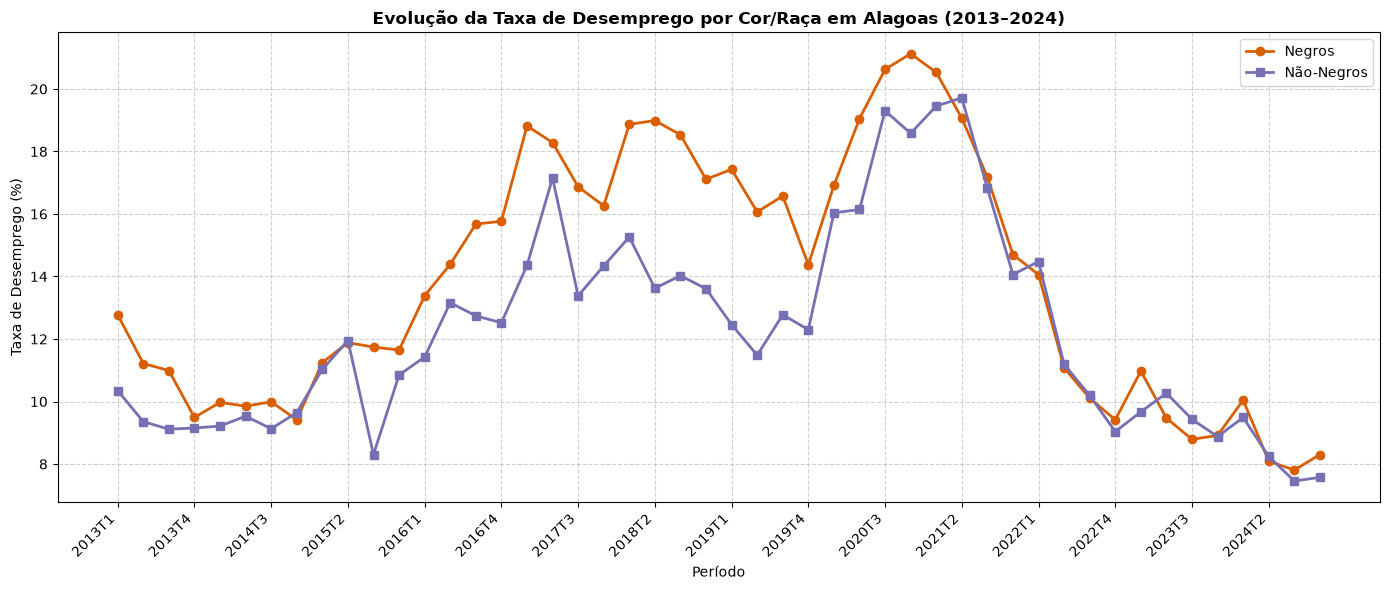

In [75]:
# Cria uma cópia da tabela
grafico = taxa_desocupacao_trimestre.copy()

# Cria o período (2013T1, 2013T2, ...)
grafico["Periodo"] = (
    grafico["ano"].astype(str)
    + "T"
    + grafico["trimestre"].astype(str)
)

# Separa os grupos
negros = grafico[grafico["grupo_etnico"] == "Negra"]
nao_negros = grafico[grafico["grupo_etnico"] == "Não-Negra"]

# Gráfico
plt.figure(figsize=(14, 6))

plt.plot(
    negros["Periodo"],
    negros["Taxa de desocupação"],
    label="Negros",
    color="#d95f02",
    marker="o",
    linewidth=2
)

plt.plot(
    nao_negros["Periodo"],
    nao_negros["Taxa de desocupação"],
    label="Não-Negros",
    color="#7570b3",
    marker="s",
    linewidth=2
)

plt.title(
    "Evolução da Taxa de Desemprego por Cor/Raça em Alagoas (2013–2024)",
    fontweight="bold"
)

plt.ylabel("Taxa de Desemprego (%)")
plt.xlabel("Período")

plt.grid(True, linestyle="--", alpha=0.6)

# Mostra um rótulo a cada 3 trimestres
plt.xticks(
    range(0, len(negros), 3),
    negros["Periodo"].iloc[::3],
    rotation=45,
    ha="right"
)

plt.legend()

plt.tight_layout()
plt.show()

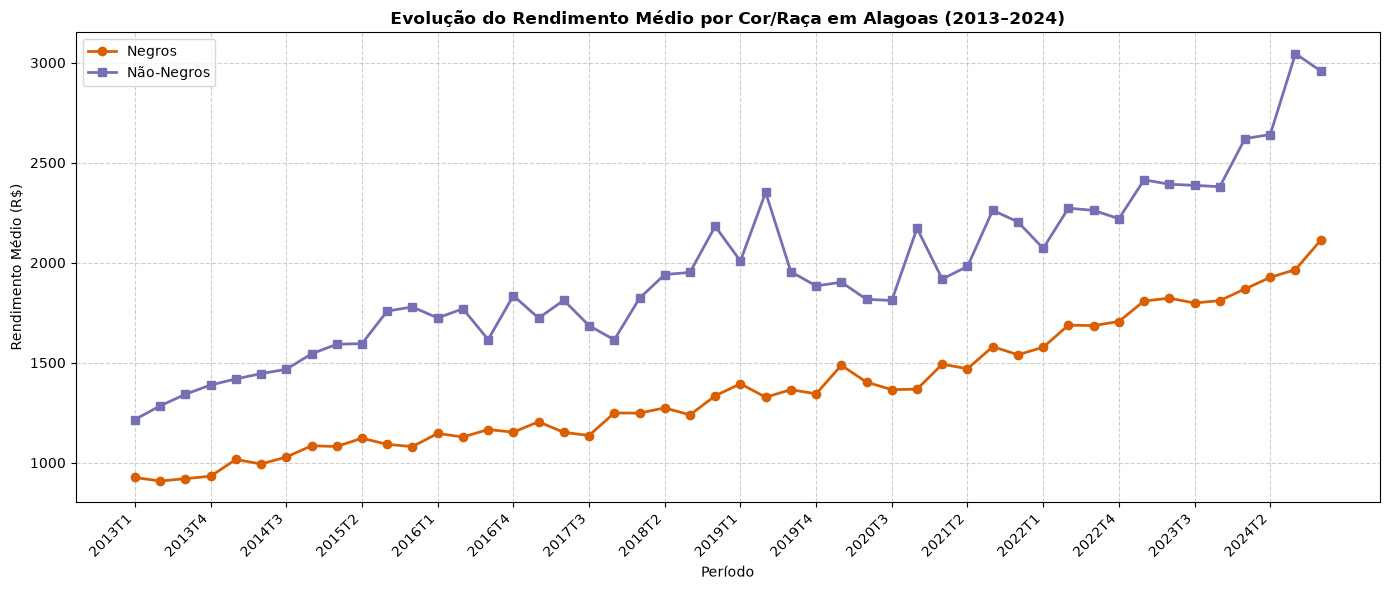

In [76]:
# Cria uma cópia da tabela
grafico = renda_media_trimestre.copy()

# Cria o período (2013T1, 2013T2, ...)
grafico["Periodo"] = (
    grafico["ano"].astype(str)
    + "T"
    + grafico["trimestre"].astype(str)
)

# Separa os grupos
negros = grafico[grafico["grupo_etnico"] == "Negra"]
nao_negros = grafico[grafico["grupo_etnico"] == "Não-Negra"]

# Gráfico
plt.figure(figsize=(14, 6))

plt.plot(
    negros["Periodo"],
    negros["Rendimento médio"],
    label="Negros",
    color="#d95f02",
    marker="o",
    linewidth=2
)

plt.plot(
    nao_negros["Periodo"],
    nao_negros["Rendimento médio"],
    label="Não-Negros",
    color="#7570b3",
    marker="s",
    linewidth=2
)

plt.title(
    "Evolução do Rendimento Médio por Cor/Raça em Alagoas (2013–2024)",
    fontweight="bold"
)

plt.ylabel("Rendimento Médio (R$)")
plt.xlabel("Período")

plt.grid(True, linestyle="--", alpha=0.6)

# Mostra um rótulo a cada 3 trimestres
plt.xticks(
    range(0, len(negros), 3),
    negros["Periodo"].iloc[::3],
    rotation=45,
    ha="right"
)

plt.legend()

plt.tight_layout()
plt.show()

In [80]:
df_base_limpa["rendimento_mensal"] = pd.to_numeric(df_base_limpa["rendimento_mensal"], errors='coerce')
df_base_limpa["peso_amostral"] = pd.to_numeric(df_base_limpa["peso_amostral"], errors='coerce')


df_analise = df_base_limpa[df_base_limpa["rendimento_mensal"] > 0].copy()

# Coluna com a renda multiplicada pelo peso
df_analise["renda_expandida"] = df_analise["rendimento_mensal"] * df_analise["peso_amostral"]

grupo_etnico = df_analise.groupby("grupo_etnico")[["renda_expandida", "peso_amostral"]].sum().reset_index()
grupo_etnico["Rendimento médio"] = (grupo_etnico["renda_expandida"] / grupo_etnico["peso_amostral"]).round(2)

# Filtra resultado
renda_media = grupo_etnico[["grupo_etnico", "Rendimento médio"]]

renda_media

,grupo_etnico,Rendimento médio
0,Negra,1379.80
1,Não-Negra,1994.83


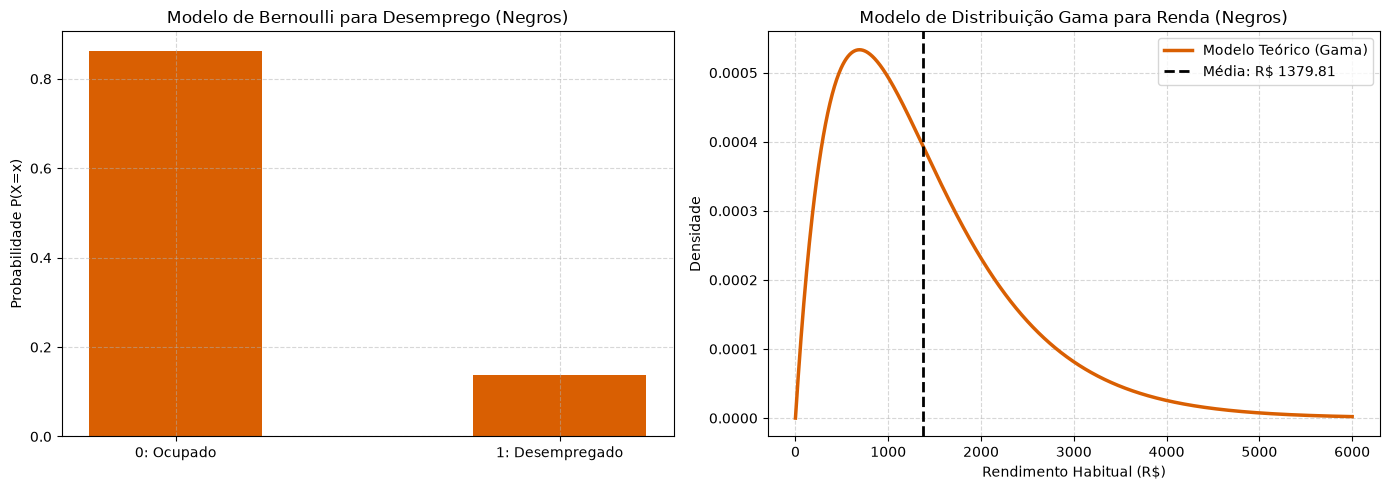

In [81]:
# Probabilidade de desemprego dos negros
p_desemprego = taxa_negros      

# Média ponderada da renda dos negros
media_renda = 1379.81           
# Parâmetros da distribuição Gama
alpha = 2.0                    
theta = media_renda / alpha

plt.figure(figsize=(14,5))

# Distribuição de Bernoulli

plt.subplot(1,2,1)

x = np.array([0,1])

pmf = stats.bernoulli.pmf(x,p_desemprego)

plt.bar(
    x,
    pmf,
    color="#d95f02",
    width=0.45
)

plt.xticks(
    [0,1],
    ["0: Ocupado","1: Desempregado"]
)

plt.ylabel("Probabilidade P(X=x)")
plt.title("Modelo de Bernoulli para Desemprego (Negros)")
plt.grid(True,linestyle="--",alpha=0.5)

# Distribuição Gama

plt.subplot(1,2,2)

x = np.linspace(0,6000,1000)

pdf = stats.gamma.pdf(
    x,
    a=alpha,
    scale=theta
)

plt.plot(
    x,
    pdf,
    color="#d95f02",
    linewidth=2.5,
    label="Modelo Teórico (Gama)"
)

plt.axvline(
    media_renda,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Média: R$ {media_renda:.2f}"
)

plt.xlabel("Rendimento Habitual (R$)")
plt.ylabel("Densidade")
plt.title("Modelo de Distribuição Gama para Renda (Negros)")

plt.legend()

plt.grid(True,linestyle="--",alpha=0.5)

plt.tight_layout()

plt.savefig(
    "GRUPO_1_modelos_teoricos.png",
    dpi=300
)

plt.show()

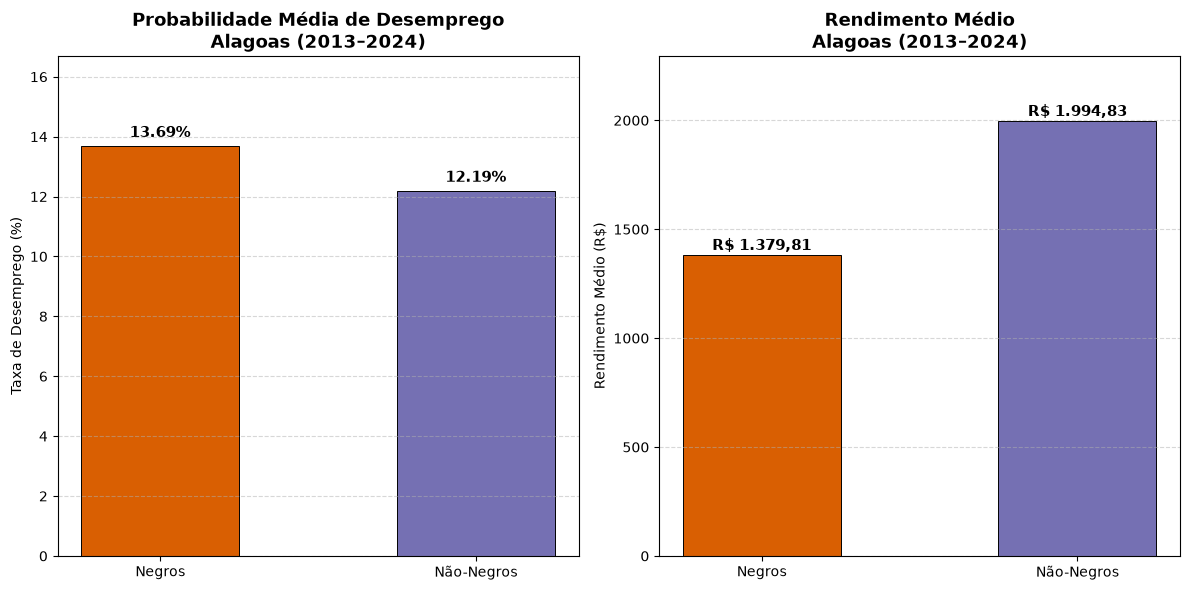

In [82]:
categorias = ["Negros", "Não-Negros"]

# Probabilidade de desemprego 
probabilidades = [
    taxa_negros * 100,
    taxa_nao * 100
]

# Rendimento médio (R$)
rendas = [
    1379.81,
    1994.83
]

cores = ["#d95f02", "#7570b3"]

plt.figure(figsize=(12,6))

# Desemprego

plt.subplot(1,2,1)

barras = plt.bar(
    categorias,
    probabilidades,
    color=cores,
    width=0.5,
    edgecolor="black",
    linewidth=0.7
)

plt.title(
    "Probabilidade Média de Desemprego\nAlagoas (2013–2024)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Taxa de Desemprego (%)")

plt.ylim(0,max(probabilidades)+3)

plt.grid(axis="y",linestyle="--",alpha=0.5)

for barra in barras:

    altura = barra.get_height()

    plt.text(
        barra.get_x()+barra.get_width()/2,
        altura+0.3,
        f"{altura:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Renda

plt.subplot(1,2,2)

barras = plt.bar(
    categorias,
    rendas,
    color=cores,
    width=0.5,
    edgecolor="black",
    linewidth=0.7
)

plt.title(
    "Rendimento Médio\nAlagoas (2013–2024)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Rendimento Médio (R$)")

plt.ylim(0,max(rendas)+300)

plt.grid(axis="y",linestyle="--",alpha=0.5)

for barra in barras:

    altura = barra.get_height()

    plt.text(
        barra.get_x()+barra.get_width()/2,
        altura+25,
        f"R$ {altura:,.2f}".replace(",", "X").replace(".", ",").replace("X","."),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "probabilidade_renda_barras.png",
    dpi=300
)

plt.show()